<a href="https://colab.research.google.com/github/subhamoymahajan/PolyGen/blob/main/PolymerGeneration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
!pip install rdkit


# **Simple small molecule**

## SMILE strings can be used to generate molecules in RDKit.

In [10]:
import rdkit
from rdkit import Chem

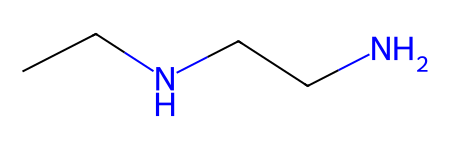

In [11]:
smile="CCNCCN"
mol = Chem.MolFromSmiles(smile)
display(mol)


## **3D structures can be generated by:**

### 1. Adding explicity hydrogen.
### 2. Applying forcefield parameters.
### 3. Optimizing the 3D structure.

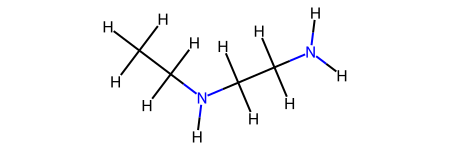

In [46]:
mol_H = Chem.AddHs(mol)
display(mol_H)

In [47]:
from rdkit.Chem import AllChem
params = Chem.AllChem.ETKDGv3()
params.randomSeed = 42
params.pruneRmsThresh = 0.5   # optional: remove near-duplicate conformers

conf_ids = Chem.AllChem.EmbedMultipleConfs(mol_H, numConfs=3, params=params)

In [6]:
!pip install py3Dmol

In [15]:
import py3Dmol
def show_3D(mol, conf_id=None, width=400, height=400):
  view = py3Dmol.view(width=width, height=height)
  if conf_id is None:
    mb = Chem.MolToMolBlock(mol)
  else:
    mb = Chem.MolToMolBlock(mol, confId= conf_id)
  view.addModel(mb, "mol")
  view.setStyle({"stick": {}})
  view.zoomTo()
  view.show()

In [49]:
conf_ids = [conf.GetId() for conf in mol_H.GetConformers()]
show_3D(mol_H, conf_ids[0])


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [50]:
show_3D(mol_H, conf_ids[1])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## **Iterate over conformers to find most stable conformer**

In [52]:
params = Chem.AllChem.ETKDGv3()
params.randomSeed = 42
params.pruneRmsThresh = 0.5   # optional: remove near-duplicate conformers

conf_ids = Chem.AllChem.EmbedMultipleConfs(mol_H, numConfs=100, params=params)
min_cid=-1
min_energy = 10000000000000
for cid in conf_ids:
    Chem.AllChem.UFFOptimizeMolecule(mol_H, confId=cid)
    ff = AllChem.UFFGetMoleculeForceField(mol_H, confId=cid)
    energy = ff.CalcEnergy()
    #print('confid',cid,'energy',energy,'kcal/mol')   # kcal/mol
    if energy < min_energy:
        min_cid = cid
        min_energy = energy

print('min_cid',min_cid,'min_energy',min_energy)
show_3D(mol_H,min_cid)

min_cid 0 min_energy 5.346981786296473


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

# **Polymer-SMILES**

## Polymer SMILES, are simply SMILE strings of monomers with `*` characters that denotes polymerization points. For linear polymers, it is assumed that the first `*` in a monomer binds with second `*` in the next monomer, and so on. Without proper definitions, the polymer may not be well-defined if there are more than two `*` characters. Additionally, `*` characters should only have one neighboring atom and it should not be another `*`.

## In the 2D representation, RDKit can handle `*` characters like a normal molecule.

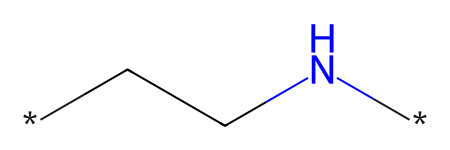

In [53]:
smile="*CCN*"
mol = Chem.MolFromSmiles(smile)
display(mol)

## However, 3D structures cannot be generated with `*` atoms. One way to generate the 3D structures is to mutate `*` atoms to hydrogens.

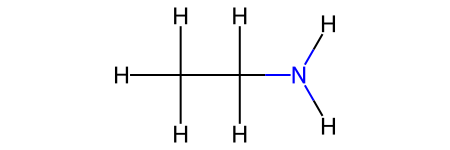

In [54]:
smi = '*CCN*'
mol = Chem.MolFromSmiles(smi)
mol_H = Chem.AddHs(mol)
star_idx =[]
for atom in mol_H.GetAtoms():
  if atom.GetSymbol()=='*':
    atom.SetAtomicNum(1) #Changing to Hydrogen
    star_idx.append(atom.GetIdx())

display(mol_H)

In [55]:
params = Chem.AllChem.ETKDGv3()
params.randomSeed = 42
params.pruneRmsThresh = 0.5   # optional: remove near-duplicate conformers

conf_ids = Chem.AllChem.EmbedMultipleConfs(mol_H, numConfs=1, params=params)
show_3D(mol_H, conf_ids[0])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

# **3D-Polymer construction logic**

## Each linear-polymer monomer has two `*` ends, and `*` atoms of consecutive monomers will overlap exactly.

## Therefore, monomer 3D-coordinates are generated once, then translated and rotated, such that the end-to-end vector is along x-axis, and both `*` atoms line on the x-axis.

## Then for each new monomer the 3D-coordinates can betranslated along x-axis to ensure the `*` atoms overlap.

## The polymer structures can then be packed into a box and energy minimized, so that stable polymer configurations are determined.

### **Nuances**:
### 1. We deliberately ignore angle and dihedral constraints between the monomers. Otherwise, the generated-polymer may have overlapping atoms.
### 2. Stereo-chemistry between monomers will not be respected.

In [2]:
from rdkit import Chem
from rdkit.Chem import AllChem
import copy
import os
import random
from scipy.spatial.transform import Rotation as R
from rdkit.Geometry import Point3D
import numpy as np


def get_star_neigh(m):
    sneigh=[]
    star=[]
    for atom in m.GetAtoms():
        if atom.GetAtomicNum()==0:
            for neigh in atom.GetNeighbors():
                sneigh.append(neigh.GetIdx())
                star.append(atom.GetIdx())
                break
    return sneigh,star

def build_polymer(monomer, n):
    if n < 1:
        raise ValueError("n must be >= 1")
    sneigh,star = get_star_neigh(monomer)

    Natoms = len(monomer.GetAtoms())
    #print(sneigh,Natoms)


    poly = copy.deepcopy(monomer)  # start with a copy

    for i in range(n - 1):
        poly = Chem.CombineMols(poly, copy.deepcopy(monomer))
        poly = Chem.RWMol(poly)
        poly.AddBond( sneigh[1]+i*Natoms, sneigh[0]+(i+1)*Natoms, Chem.BondType.SINGLE)

    for i in range(n):
        for j in range(Natoms):
            atom=poly.GetAtomWithIdx(i*Natoms+j)
            info = Chem.AtomPDBResidueInfo()
            info.SetResidueName('M'+str(i+1))
            info.SetResidueNumber(i+1)
            atom.SetMonomerInfo(info)
            atom.SetIntProp("org_id",j)

    for i in range(n-1,-1,-1):
        if i!=n-1:
            poly.RemoveAtom(star[1]+i*Natoms)
        else:
            atom=poly.GetAtomWithIdx(star[1]+i*Natoms)
            atom.SetAtomicNum(1)
        if i!=0:
            poly.RemoveAtom(star[0]+i*Natoms)
        else:
            atom=poly.GetAtomWithIdx(star[0]+i*Natoms)
            atom.SetAtomicNum(1)
    Chem.SanitizeMol(poly)

    return poly

def gen_nmer(smile,outname,n):
    # Example monomer: *-CH2-CH2-*
    monomer = Chem.MolFromSmiles(smile)
    monomer = Chem.AddHs(monomer)

    #Replace * with H
    monomer_H = copy.deepcopy(monomer)
    sneigh,star = get_star_neigh(monomer_H)
    for idx in star:
        atom=monomer_H.GetAtomWithIdx(idx)
        atom.SetAtomicNum(1)
    success=False
    for i in range(10):
        try:
            params = AllChem.ETKDG()
            seed = random.randint(1, 1_000_000)
            params.randomSeed = seed
            AllChem.EmbedMolecule(monomer_H, params)

            # 4. Optimize geometry
            AllChem.UFFOptimizeMolecule(monomer_H)
            success=True
            break
        except:
            pass
    if not success:
        Print('Failed')

    mono_conf = monomer_H.GetConformer()
    pos_ref = np.array(mono_conf.GetPositions())
    origin = pos_ref[star[0],:]
    pos_ref -= origin

    #Rotate  to get the other star from v - > (1,0,0)
    end_pos = np.array(pos_ref[star[1],:])
    v = end_pos/ np.linalg.norm(end_pos)
    target = np.array([1.0,0.0,0.0])

    rot,rmsd = R.align_vectors([target],[v])
    pos_ref_rot = rot.apply(pos_ref)

    # Example: 4-mer from *CC*
    poly = build_polymer(monomer, n)

    #Get positions
    all_pos = np.zeros((len(pos_ref_rot)*n,3))
    for ii in range(len(pos_ref_rot)):
        #print(all_pos[ii,:], pos_ref_rot[ii,:])
        all_pos[ii,: ] = pos_ref_rot[ii,:]

    for i in range(1,n):
        new_start = all_pos[(i-1)*len(pos_ref_rot)+star[1],:]
        old_start = pos_ref_rot[star[0],:]
        trans = np.subtract(new_start,old_start)
        for ii in range(len(pos_ref_rot)):
            all_pos[i*len(pos_ref_rot) + ii, :] = trans+ pos_ref_rot[ii,:]


    conf = Chem.Conformer(poly.GetNumAtoms())

    #Apply to the polymer
    for atom in poly.GetAtoms():
        info = atom.GetPDBResidueInfo()
        resid = info.GetResidueNumber()
        org_id = atom.GetIntProp("org_id")
        idx = atom.GetIdx()
        cur_pos=all_pos[(resid-1)*len(pos_ref_rot)+org_id,:]
        conf.SetAtomPosition(idx, Point3D(float(cur_pos[0]), float(cur_pos[1]), float(cur_pos[2])))

    poly.RemoveAllConformers()
    poly.AddConformer(conf, assignId=True)
    # 4. Optimize geometry
    AllChem.UFFOptimizeMolecule(poly)

    # 5. Save output
    if outname[-4:]=='.pdb':
      Chem.MolToPDBFile(poly, outname)
    elif outname[-4:] == '.sdf':
      w = Chem.SDWriter(outname)
      w.write(poly)
      w.close()
    return poly


#smile="*c1ccc(Oc2ccc(Oc3ccc(-n4c(=O)c5cc6c(=O)n(*)c(=O)c6cc5c4=O)cc3)cc2C(C)(C)C)cc1"
#smile = "*CN1CN(*)Cc2c1ccc1c2cc(O)c2cc(*)c(*)cc21"
#gen_nmer(smile,"test.pdb",20)


In [3]:
smi="*CCN*"
poly=gen_nmer(smi,"test.sdf",250)

In [16]:
show_3D(poly)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.